# Model Evaluation, Explainability & Insights

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")


### Load the prepared data and model results

In [2]:
df = pd.read_csv("./dataset/feature_engineered_data.csv")
results_df = pd.read_csv("role3_model_results.csv")


### Pick the best model for each domain

In [3]:
best_models = results_df[
    results_df["Model"] == "XGBoost"
].reset_index(drop=True)

# best_models = (
#     results_df.sort_values(
#         by=["Domain", "TestAccuracy"],
#         ascending=[True, False]
#     )
#     .groupby("Domain")
#     .first()
#     .reset_index()
# )


target_map = {
    "food": "food_security_label",
    "fuel": "fuel_security_label",
    "child": "child_security_label",
}


### Create a helper function to evaluate one domain
#### It prints metrics and draws confusion matrix + ROC curve

In [4]:
def evaluate_domain(model, model_name, domain, X, y):

    le = LabelEncoder()
    y = le.fit_transform(y.astype(str))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Errors
    train_error = 1 - train_acc
    test_error = 1 - test_acc
    error_gap = test_error - train_error

    # Other Metrics
    precision = precision_score(
        y_test, y_test_pred, average="weighted", zero_division=0
    )

    recall = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)

    f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    # Print Metrics
    print("=" * 80)
    print("DOMAIN:", domain.upper())
    print("BEST MODEL:", model_name)
    print("Train Accuracy :", round(train_acc, 4))
    print("Test Accuracy  :", round(test_acc, 4))
    print("Train Error    :", round(train_error, 4))
    print("Test Error     :", round(test_error, 4))
    print("Error Gap      :", round(error_gap, 4))
    print("F1 Score       :", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )

    plt.title(f"{domain.upper()} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # 2. Train vs Test Error Graph
    error_df = pd.DataFrame(
        {"Type": ["Train Error", "Test Error"], "Value": [train_error, test_error]}
    )

    plt.figure(figsize=(4, 4))
    sns.barplot(data=error_df, x="Type", y="Value")
    plt.title(f"{domain.upper()} - Train vs Test Error")
    plt.ylabel("Error")
    plt.ylim(0, 1)
    plt.show()

    # 3. ROC Curve

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)

        n_classes = len(np.unique(y_test))
        y_bin = label_binarize(y_test, classes=np.arange(n_classes))

        plt.figure(figsize=(4, 4))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"{domain.upper()} ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

    return {
        "Domain": domain,
        "BestModel": model_name,
        "Accuracy": test_acc,
        "F1Score": f1,
        "TrainError": train_error,
        "TestError": test_error,
        "ErrorGap": error_gap,
    }

### Step 5: Run evaluation for all best models and build summary rows

DOMAIN: CHILD
BEST MODEL: XGBoost
Train Accuracy : 0.838
Test Accuracy  : 0.7926
Train Error    : 0.162
Test Error     : 0.2074
Error Gap      : 0.0453
F1 Score       : 0.8344

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       589
           1       0.36      0.40      0.38        55
           2       0.13      0.45      0.20        29
           3       0.20      0.29      0.24         7

    accuracy                           0.79       680
   macro avg       0.42      0.50      0.43       680
weighted avg       0.89      0.79      0.83       680



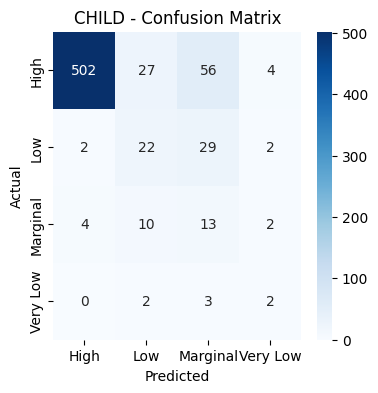

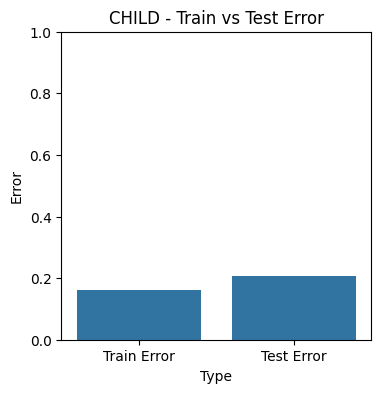

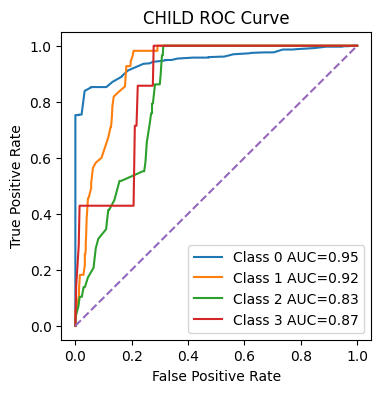

DOMAIN: FOOD
BEST MODEL: XGBoost
Train Accuracy : 0.6681
Test Accuracy  : 0.5853
Train Error    : 0.3319
Test Error     : 0.4147
Error Gap      : 0.0828
F1 Score       : 0.5363

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.89      0.77       353
           1       0.30      0.21      0.25       103
           2       0.36      0.09      0.14       110
           3       0.44      0.45      0.45       114

    accuracy                           0.59       680
   macro avg       0.45      0.41      0.40       680
weighted avg       0.53      0.59      0.54       680



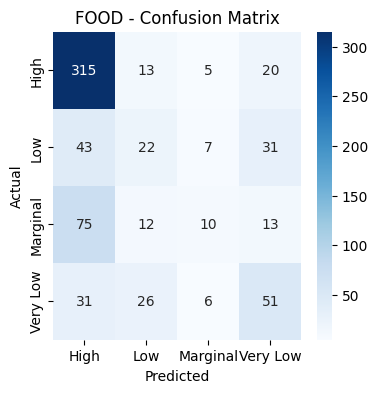

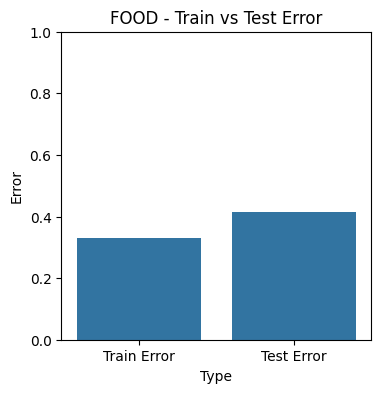

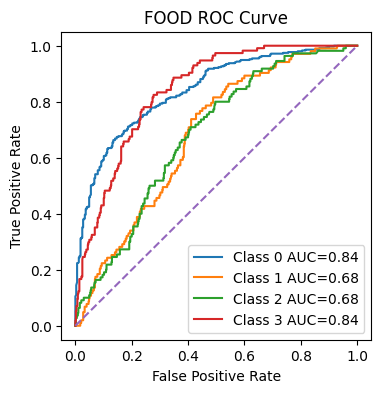

DOMAIN: FUEL
BEST MODEL: XGBoost
Train Accuracy : 0.7153
Test Accuracy  : 0.6824
Train Error    : 0.2847
Test Error     : 0.3176
Error Gap      : 0.0329
F1 Score       : 0.6584

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.48      0.46        86
           1       0.36      0.21      0.26       152
           2       0.79      0.88      0.83       442

    accuracy                           0.68       680
   macro avg       0.53      0.52      0.52       680
weighted avg       0.65      0.68      0.66       680



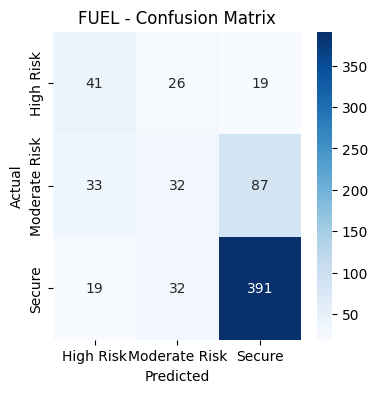

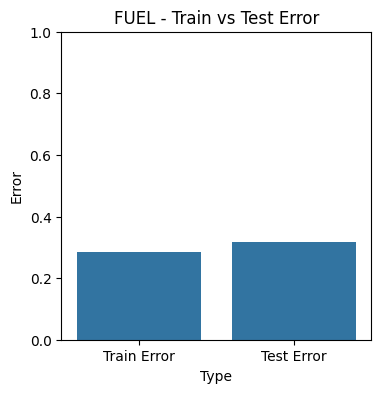

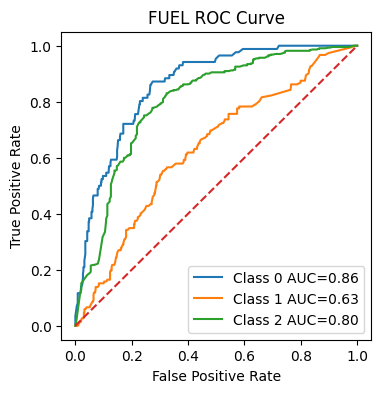

In [5]:
summary_rows = []

for _, row in best_models.iterrows():
    domain = row["Domain"]
    model_name = row["Model"]
    model_path = row["ModelPath"]

    model = joblib.load(model_path)
    target_col = target_map[domain]

    X = df.drop(
        columns=[
            "food_security_label",
            "fuel_security_label",
            "child_security_label",
        ],
        errors="ignore",
    )
    y = df[target_col].copy()

    # Remove rows where target is missing
    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    row_summary = evaluate_domain(model, model_name, domain, X, y)
    summary_rows.append(row_summary)

summary_df = pd.DataFrame(summary_rows)


In [6]:
# Step 6: Show summary table
print("=" * 80)
print("BEST MODEL SUMMARY")
print("=" * 80)

display(summary_df)


BEST MODEL SUMMARY


,Domain,BestModel,Accuracy,F1Score,TrainError,TestError,ErrorGap
0,child,XGBoost,0.792647,0.834376,0.162003,0.207353,0.045350
1,food,XGBoost,0.585294,0.536283,0.331861,0.414706,0.082845
2,fuel,XGBoost,0.682353,0.658372,0.284732,0.317647,0.032915


## Compare accuracy by domain

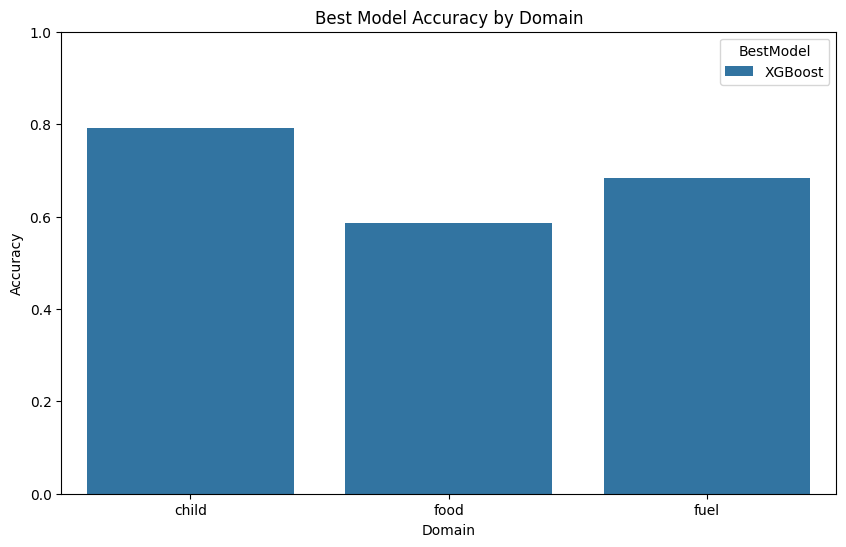

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, x="Domain", y="Accuracy", hue="BestModel")
plt.title("Best Model Accuracy by Domain")
plt.ylim(0, 1)
plt.show()


## Compare overfitting gap by domain

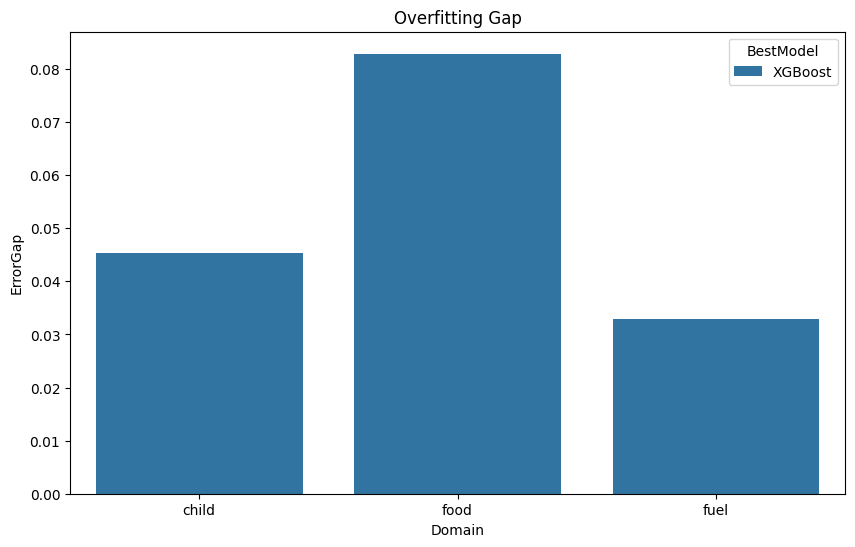

In [8]:

plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, x="Domain", y="ErrorGap", hue="BestModel")
plt.title("Overfitting Gap")
plt.show()


## Domain Wise Accuracy Graph Of All Models

In [9]:
def plot_all_models_train_test_accuracy(results_df):
    plot_df = results_df.melt(
        id_vars=["Domain", "Model"],
        value_vars=["TrainAccuracy", "TestAccuracy"],
        var_name="Metric",
        value_name="Accuracy",
    )

    # Rename labels
    plot_df["Metric"] = plot_df["Metric"].replace(
        {"TrainAccuracy": "Train Accuracy", "TestAccuracy": "Test Accuracy"}
    )

    for domain in results_df["Domain"].unique():
        domain_df = plot_df[plot_df["Domain"] == domain]
        sns.barplot(data=domain_df, x="Model", y="Accuracy", hue="Metric")
        plt.title(f"{domain.upper()} - Train vs Test Accuracy")
        plt.xlabel("Model")
        plt.ylabel("Accuracy")
        plt.ylim(0, 1)
        plt.show()

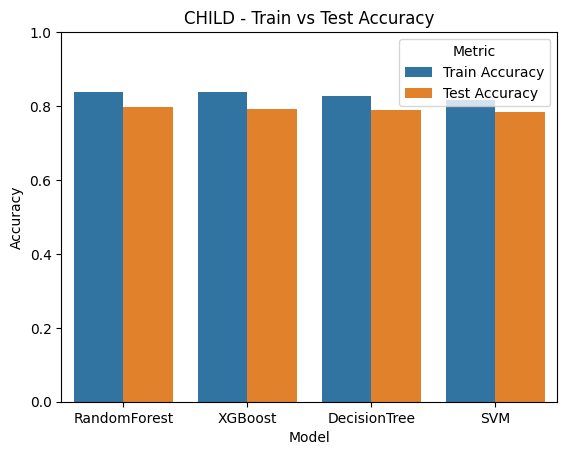

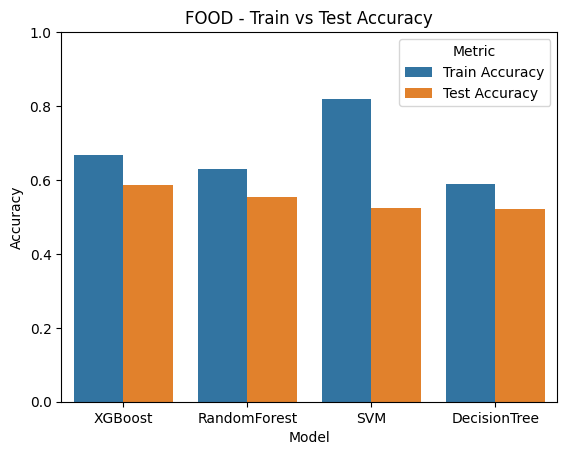

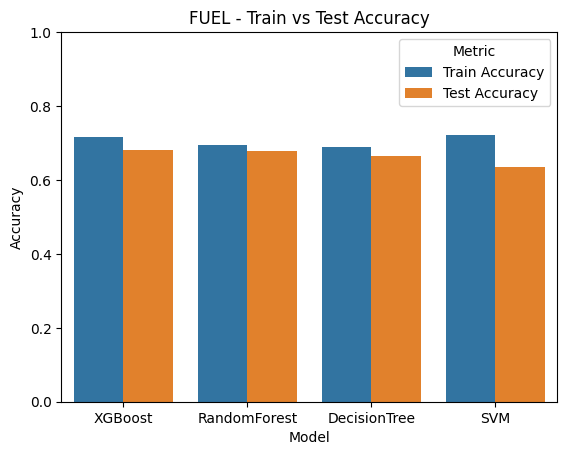

In [10]:
plot_all_models_train_test_accuracy(results_df)

## Domain Wise Train & Test Error Graph Of All Models

In [11]:
def plot_all_models_train_test_error(results_df):
    plot_df = results_df.melt(
        id_vars=["Domain", "Model"],
        value_vars=["TrainError", "TestError"],
        var_name="Metric",
        value_name="Error",
    )

    # Rename labels
    plot_df["Metric"] = plot_df["Metric"].replace(
        {"TrainError": "Train Error", "TestError": "Test Error"}
    )

    for domain in results_df["Domain"].unique():
        domain_df = plot_df[plot_df["Domain"] == domain]
        sns.barplot(data=domain_df, x="Model", y="Error", hue="Metric")
        plt.title(f"{domain.upper()} - Train vs Test Error")
        plt.xlabel("Model")
        plt.ylabel("Error")
        plt.ylim(0, 1)
        plt.show()

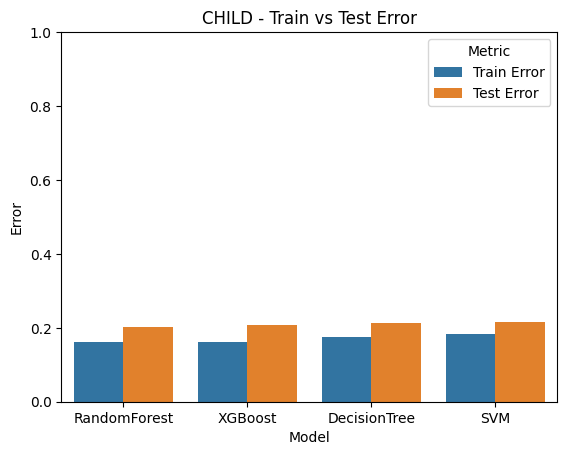

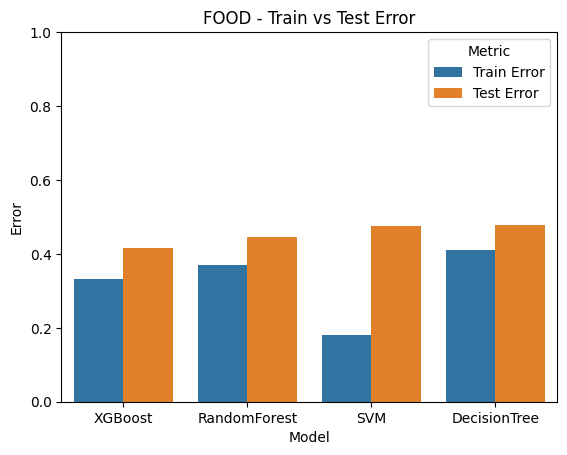

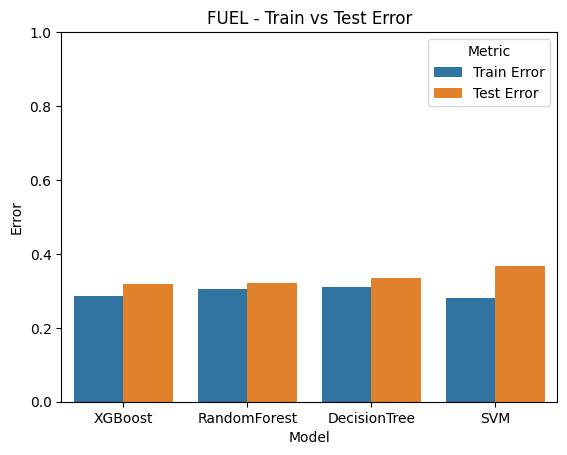

In [12]:
plot_all_models_train_test_error(results_df)